In [217]:
# Importamos las librerías necesarias
import pandas as pd
import numpy as np
pd.set_option("display.max_columns", None)
import seaborn as sns
import matplotlib.pyplot as plt

In [218]:
# Para imputación de nulos usando métodos estadísticos avanzados
from sklearn.impute import SimpleImputer 
from sklearn.experimental import enable_iterative_imputer # Necesario para IterativeImputer
from sklearn.impute import IterativeImputer 
from sklearn.impute import KNNImputer 

FASE 1 - ANÁLISIS EXPLORATORIO INICIAL:
Homogenización columnas
Limpieza datos
Gestión datos nulos

In [219]:
df_hr = pd.read_csv("hr.csv")
df_hr.head(2)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41.0,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,sALES eXECUTIVE,4.0,Single,5993.0,19479,8,Y,Yes,11,3,1,80.0,0,8,0.0,1,6,4,0,5.0
1,49.0,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,rESEARCH sCIENTIST,2.0,Married,5130.0,24907,1,Y,No,23,4,4,NaN,1,10,3.0,3,10,7,1,7.0


In [220]:
def exploracion_basica(df):
    print(f"Las dos primeras filas son:")
    display(df.head(2))
    print("=" * 50)
    print(f"Las dos últimas filas son:")
    display(df.tail(2))
    print("=" * 50)
    print(f"Las dos filas aleatorias son:")
    display(df.sample(2)) 
    print("=" * 50)
    print(f"Información sobre DataFrame:")
    print(df.info())
    print("=" * 50)
    print(f"El dataframe tiene {df.shape[0]} filas y {df.shape[1]} columnas.")
    return df

In [221]:
df_hr = exploracion_basica(df_hr)

Las dos primeras filas son:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41.0,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,sALES eXECUTIVE,4.0,Single,5993.0,19479,8,Y,Yes,11,3,1,80.0,0,8,0.0,1,6,4,0,5.0
1,49.0,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,rESEARCH sCIENTIST,2.0,Married,5130.0,24907,1,Y,No,23,4,4,NaN,1,10,3.0,3,10,7,1,7.0


Las dos últimas filas son:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1472,24.0,Yes,Travel_Rarely,240,Human Resources,22,1,Human Resources,1,1714,4,Male,58,1,1,hUMAN rESOURCES,3.0,Married,1555.0,11585,1,Y,No,11,3,3,80.0,1,1,2.0,3,1,0,0,0.0
1473,45.0,No,Travel_Rarely,1339,Research & Development,7,3,Life Sciences,1,86,2,Male,59,3,3,rESEARCH sCIENTIST,1.0,Divorced,9724.0,18787,2,Y,No,17,3,3,NaN,1,25,2.0,3,1,0,0,0.0


Las dos filas aleatorias son:


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
724,24.0,No,Travel_Rarely,1206,Research & Development,17,1,Medical,1,1009,4,Female,41,2,2,mANUFACTURING dIRECTOR,3.0,Divorced,4377.0,24117,1,Y,No,15,3,2,80.0,2,5,6.0,3,4,2,3,2.0
681,38.0,No,Travel_Rarely,1333,Research & Development,1,3,Technical Degree,1,950,4,Female,80,3,3,rESEARCH dIRECTOR,1.0,Married,13582.0,16292,1,Y,No,13,3,2,80.0,1,15,3.0,3,15,12,5,11.0


Información sobre DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1474 entries, 0 to 1473
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       1401 non-null   float64
 1   Attrition                 1474 non-null   object 
 2   BusinessTravel            1357 non-null   object 
 3   DailyRate                 1474 non-null   int64  
 4   Department                1445 non-null   object 
 5   DistanceFromHome          1474 non-null   int64  
 6   Education                 1474 non-null   int64  
 7   EducationField            1416 non-null   object 
 8   EmployeeCount             1474 non-null   int64  
 9   EmployeeNumber            1474 non-null   int64  
 10  EnvironmentSatisfaction   1474 non-null   int64  
 11  Gender                    1474 non-null   object 
 12  HourlyRate                1474 non-null   int64  
 13  JobInvolvement            1474 non

In [222]:
df_hr.sample(2)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
257,40.0,No,Travel_Rarely,1416,Research & Development,2,2,Medical,1,352,1,Male,49,3,5,rESEARCH dIRECTOR,3.0,Divorced,19436.0,5949,0,Y,No,19,3,4,80.0,1,22,5.0,3,21,7,3,NaN
941,30.0,No,Travel_Rarely,1138,Research & Development,6,3,Technical Degree,1,1311,1,Female,48,2,2,lABORATORY tECHNICIAN,4.0,Married,4627.0,23631,0,Y,No,12,3,1,80.0,1,10,6.0,3,9,2,6,7.0


In [223]:
# añadir _ a los nombres de las columnas y poner en minúscula

df_hr.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

In [224]:
import re  #importar regex para insertar guines bajsos antes de mayúsculas internas. Buena práctica
#r'(?<!^)(?=[A-Z])' significa “encuentra cada mayúscula que no esté al inicio, y pon un _ antes”.


df_hr.columns = (
    df_hr.columns
    # 1. Inserta _ entre minúscula y Mayúscula (ej. MonthlyIncome -> Monthly_Income)
    .str.replace(r'([a-z])([A-Z])', r'\1_\2', regex=True)
    # 2. Inserta _ entre una letra y el primer número que encuentre (ej. Over18 -> Over_18)
    .str.replace(r'([a-zA-Z])([0-9])', r'\1_\2', regex=True)
    # 3. Convierte todo a minúsculas
    .str.lower()
)

In [225]:
df_hr.rename(columns={'over18': 'over_18'}, inplace=True)
df_hr.head(2)


,age,attrition,business_travel,daily_rate,department,distance_from_home,education,education_field,employee_count,employee_number,environment_satisfaction,gender,hourly_rate,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,monthly_rate,num_companies_worked,over_18,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,standard_hours,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager
0,41.0,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,sALES eXECUTIVE,4.0,Single,5993.0,19479,8,Y,Yes,11,3,1,80.0,0,8,0.0,1,6,4,0,5.0
1,49.0,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,rESEARCH sCIENTIST,2.0,Married,5130.0,24907,1,Y,No,23,4,4,NaN,1,10,3.0,3,10,7,1,7.0


In [226]:
# cambair edad a int

columna_edad_a_int = ['age']

for col in columna_edad_a_int:
    df_hr[col] = df_hr[col].astype('Int64')

df_hr[columna_edad_a_int].dtypes

age    Int64
dtype: object

In [227]:
df_hr['job_role'].unique()

array([' sALES eXECUTIVE ', ' rESEARCH sCIENTIST ',
       ' lABORATORY tECHNICIAN ', ' mANUFACTURING dIRECTOR ',
       ' hEALTHCARE rEPRESENTATIVE ', ' mANAGER ',
       ' sALES rEPRESENTATIVE ', ' rESEARCH dIRECTOR ',
       ' hUMAN rESOURCES '], dtype=object)

In [228]:
df_hr['job_role'] = df_hr['job_role'].str.strip().str.lower().str.replace(r'\s+', '_', regex=True)
df_hr.head(2)

,age,attrition,business_travel,daily_rate,department,distance_from_home,education,education_field,employee_count,employee_number,environment_satisfaction,gender,hourly_rate,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,monthly_rate,num_companies_worked,over_18,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,standard_hours,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,sales_executive,4.0,Single,5993.0,19479,8,Y,Yes,11,3,1,80.0,0,8,0.0,1,6,4,0,5.0
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,research_scientist,2.0,Married,5130.0,24907,1,Y,No,23,4,4,NaN,1,10,3.0,3,10,7,1,7.0


In [229]:
df_hr['business_travel'].unique()

array(['Travel_Rarely', 'Travel_Frequently', 'Non-Travel', nan],
      dtype=object)

In [230]:
df_hr['business_travel'].value_counts(dropna=False)

business_travel
Travel_Rarely        955
Travel_Frequently    263
Non-Travel           139
NaN                  117
Name: count, dtype: int64

In [231]:
# 1. cambiar nombre de categorias: 

nuevas_categorias_business_travel = {
    'Travel_Rarely': 'rarely',
    'Travel_Frequently': 'frequently',
    'Non-Travel': 'non_travel'}



In [232]:
# aplicar el reemplazo
df_hr['business_travel'] = df_hr['business_travel'].replace(nuevas_categorias_business_travel)

In [233]:
# comprobar

df_hr.head(2)

,age,attrition,business_travel,daily_rate,department,distance_from_home,education,education_field,employee_count,employee_number,environment_satisfaction,gender,hourly_rate,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,monthly_rate,num_companies_worked,over_18,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,standard_hours,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager
0,41,Yes,rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,sales_executive,4.0,Single,5993.0,19479,8,Y,Yes,11,3,1,80.0,0,8,0.0,1,6,4,0,5.0
1,49,No,frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,research_scientist,2.0,Married,5130.0,24907,1,Y,No,23,4,4,NaN,1,10,3.0,3,10,7,1,7.0


In [234]:
df_hr['department'].unique()

array(['Sales', 'Research & Development', nan, 'Human Resources'],
      dtype=object)

In [235]:
df_hr['department'] = df_hr['department'].str.strip().str.lower().str.replace(r'\s+', '_', regex=True)


In [236]:
df_hr['department'].unique()

array(['sales', 'research_&_development', nan, 'human_resources'],
      dtype=object)

In [237]:
df_hr['marital_status'].unique()

array(['Single', 'Married', 'Divorced', nan, 'Marreid'], dtype=object)

In [238]:
df_hr['marital_status'] = df_hr['marital_status'].str.strip().str.lower().str.replace(r'\s+', '_', regex=True)

In [239]:
df_hr['marital_status'].unique()

array(['single', 'married', 'divorced', nan, 'marreid'], dtype=object)

In [240]:
nuevas_categorias_marital_status = {
    'single': 'single',
    'married': 'married',
    'divorced': 'divorced',
    'marreid': 'married'
    }

In [241]:
# aplicar el reemplazo
df_hr['marital_status'] = df_hr['marital_status'].replace(nuevas_categorias_marital_status)

In [242]:
df_hr.sample(5)

,age,attrition,business_travel,daily_rate,department,distance_from_home,education,education_field,employee_count,employee_number,environment_satisfaction,gender,hourly_rate,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,monthly_rate,num_companies_worked,over_18,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,standard_hours,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager
917,34,No,rarely,131,sales,2,3,Marketing,1,1281,3,Female,86,3,2,sales_executive,1.0,single,4538.0,6039,0,Y,Yes,12,3,4,80.0,0,4,3.0,3,3,2,0,2.0
687,36,No,rarely,938,research_&_development,2,4,Medical,1,958,3,Male,79,3,1,laboratory_technician,3.0,single,2519.0,12287,4,Y,No,21,4,3,80.0,0,16,6.0,3,11,8,3,NaN
970,27,No,rarely,1291,sales,11,3,Medical,1,1364,3,Female,98,4,1,sales_representative,4.0,NaN,2534.0,6527,8,Y,No,14,3,2,80.0,1,5,4.0,3,1,0,0,0.0
1426,32,No,rarely,267,research_&_development,29,4,Life Sciences,1,2010,3,Female,49,2,1,laboratory_technician,2.0,single,2837.0,15919,1,Y,No,13,3,3,80.0,0,6,3.0,3,6,2,4,NaN
1471,53,No,rarely,1084,research_&_development,13,2,Medical,1,250,4,Female,57,4,2,manufacturing_director,1.0,divorced,4450.0,26250,1,Y,No,11,3,3,NaN,2,5,3.0,3,4,2,1,3.0


In [243]:
df_hr.dtypes

age                             Int64
attrition                      object
business_travel                object
daily_rate                      int64
department                     object
distance_from_home              int64
education                       int64
education_field                object
employee_count                  int64
employee_number                 int64
environment_satisfaction        int64
gender                         object
hourly_rate                     int64
job_involvement                 int64
job_level                       int64
job_role                       object
job_satisfaction              float64
marital_status                 object
monthly_income                float64
monthly_rate                    int64
num_companies_worked            int64
over_18                        object
over_time                      object
percent_salary_hike             int64
performance_rating              int64
relationship_satisfaction       int64
standard_hou

In [244]:
df_hr['education_field'].unique()

array(['Life Sciences', 'Other', 'Medical', nan, 'Marketing',
       'Technical Degree', 'Human Resources'], dtype=object)

In [245]:
df_hr['education_field'] = df_hr['education_field'].str.strip().str.lower().str.replace(r'\s+', '_', regex=True)

In [246]:
df_hr['education_field'].unique()

array(['life_sciences', 'other', 'medical', nan, 'marketing',
       'technical_degree', 'human_resources'], dtype=object)

In [247]:
df_hr.columns

Index(['age', 'attrition', 'business_travel', 'daily_rate', 'department',
       'distance_from_home', 'education', 'education_field', 'employee_count',
       'employee_number', 'environment_satisfaction', 'gender', 'hourly_rate',
       'job_involvement', 'job_level', 'job_role', 'job_satisfaction',
       'marital_status', 'monthly_income', 'monthly_rate',
       'num_companies_worked', 'over_18', 'over_time', 'percent_salary_hike',
       'performance_rating', 'relationship_satisfaction', 'standard_hours',
       'stock_option_level', 'total_working_years', 'training_times_last_year',
       'work_life_balance', 'years_at_company', 'years_in_current_role',
       'years_since_last_promotion', 'years_with_curr_manager'],
      dtype='object')

In [248]:
df_hr['standard_hours'].unique()

array([80., nan])

In [249]:
df_hr['over_18'].unique()

array(['Y'], dtype=object)

In [250]:
# Eliminamos columnas que no aportan información relevante para el análisis o modelado
df_hr = df_hr.drop(columns=['employee_count', 'over_18', 'standard_hours', 'monthly_rate', 'daily_rate'], errors='ignore')

In [251]:
df_hr.head(2)

,age,attrition,business_travel,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,hourly_rate,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager
0,41,Yes,rarely,sales,1,2,life_sciences,1,2,Female,94,3,2,sales_executive,4.0,single,5993.0,8,Yes,11,3,1,0,8,0.0,1,6,4,0,5.0
1,49,No,frequently,research_&_development,8,1,life_sciences,2,3,Male,61,2,2,research_scientist,2.0,married,5130.0,1,No,23,4,4,1,10,3.0,3,10,7,1,7.0


In [252]:
df_hr['gender'].unique()

array(['Female', 'Male'], dtype=object)

In [253]:
print(df_hr.duplicated().sum())

4


In [254]:
mascara_duplicados_hr = df_hr.duplicated(keep=False)
mascara_duplicados_hr


0       False
1       False
2       False
3       False
4       False
        ...  
1469    False
1470     True
1471     True
1472     True
1473     True
Length: 1474, dtype: bool

In [255]:
df_hr[mascara_duplicados_hr].sort_values(by="employee_number")

,age,attrition,business_travel,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,hourly_rate,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager
67,45,No,rarely,research_&_development,7,3,life_sciences,86,2,Male,59,3,3,research_scientist,1.0,divorced,9724.0,2,No,17,3,3,1,25,2.0,3,1,0,0,0.0
1473,45,No,rarely,research_&_development,7,3,life_sciences,86,2,Male,59,3,3,research_scientist,1.0,divorced,9724.0,2,No,17,3,3,1,25,2.0,3,1,0,0,0.0
1471,53,No,rarely,research_&_development,13,2,medical,250,4,Female,57,4,2,manufacturing_director,1.0,divorced,4450.0,1,No,11,3,3,2,5,3.0,3,4,2,1,3.0
184,53,No,rarely,research_&_development,13,2,medical,250,4,Female,57,4,2,manufacturing_director,1.0,divorced,4450.0,1,No,11,3,3,2,5,3.0,3,4,2,1,3.0
1470,28,No,rarely,sales,5,3,medical,1469,4,Male,84,3,2,sales_executive,1.0,single,8463.0,0,No,18,3,4,0,6,4.0,3,5,4,1,NaN
1041,28,No,rarely,sales,5,3,medical,1469,4,Male,84,3,2,sales_executive,1.0,single,8463.0,0,No,18,3,4,0,6,4.0,3,5,4,1,NaN
1222,24,Yes,rarely,human_resources,22,1,human_resources,1714,4,Male,58,1,1,human_resources,3.0,married,1555.0,1,No,11,3,3,1,1,2.0,3,1,0,0,0.0
1472,24,Yes,rarely,human_resources,22,1,human_resources,1714,4,Male,58,1,1,human_resources,3.0,married,1555.0,1,No,11,3,3,1,1,2.0,3,1,0,0,0.0


In [256]:
df_hr['attrition'].value_counts()

attrition
No     1236
Yes     238
Name: count, dtype: int64

In [257]:
filtrado = df_hr[['education_field', 'job_role']].value_counts().reset_index(name='count')
filtrado

,education_field,job_role,count
0,life_sciences,research_scientist,129
1,marketing,sales_executive,118
2,life_sciences,laboratory_technician,114
3,life_sciences,sales_executive,101
4,medical,research_scientist,98
5,medical,laboratory_technician,96
6,life_sciences,manufacturing_director,68
7,medical,sales_executive,64
8,life_sciences,healthcare_representative,57
9,medical,manufacturing_director,51


In [258]:
df_hr.drop_duplicates(inplace=True)
print(df_hr.duplicated().sum())

0


Gestión datos nulos:

In [259]:
df_hr.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1470 entries, 0 to 1469
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         1397 non-null   Int64  
 1   attrition                   1470 non-null   object 
 2   business_travel             1353 non-null   object 
 3   department                  1441 non-null   object 
 4   distance_from_home          1470 non-null   int64  
 5   education                   1470 non-null   int64  
 6   education_field             1412 non-null   object 
 7   employee_number             1470 non-null   int64  
 8   environment_satisfaction    1470 non-null   int64  
 9   gender                      1470 non-null   object 
 10  hourly_rate                 1470 non-null   int64  
 11  job_involvement             1470 non-null   int64  
 12  job_level                   1470 non-null   int64  
 13  job_role                    1470 non-n

In [260]:
def analisis_descriptivo(df):
    print("🔹 NUMÉRICAS")
    display(df.describe(include = "number").T)
    
    print("\n🔹 CATEGÓRICAS")
    display(df.describe(include="object").T)

In [261]:
analisis_descriptivo(df_hr)

🔹 NUMÉRICAS


,count,mean,std,min,25%,50%,75%,max
age,1397.0,36.942734,9.095617,18.0,30.0,36.0,43.0,60.0
distance_from_home,1470.0,9.192517,8.106864,1.0,2.0,7.0,14.0,29.0
education,1470.0,2.912925,1.024165,1.0,2.0,3.0,4.0,5.0
employee_number,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
environment_satisfaction,1470.0,2.721769,1.093082,1.0,2.0,3.0,4.0,4.0
hourly_rate,1470.0,65.891156,20.329428,30.0,48.0,66.0,83.75,100.0
job_involvement,1470.0,2.729932,0.711561,1.0,2.0,3.0,3.0,4.0
job_level,1470.0,2.063946,1.10694,1.0,1.0,2.0,3.0,5.0
job_satisfaction,1441.0,2.73213,1.105103,1.0,2.0,3.0,4.0,4.0
monthly_income,1456.0,6498.683379,4709.394593,1009.0,2909.0,4907.0,8353.5,19999.0



🔹 CATEGÓRICAS


,count,unique,top,freq
attrition,1470,2,No,1233
business_travel,1353,3,rarely,951
department,1441,3,research_&_development,939
education_field,1412,6,life_sciences,581
gender,1470,2,Male,882
job_role,1470,9,sales_executive,326
marital_status,1338,3,married,606
over_time,1426,2,No,1021


In [262]:
# filtramos datos categoricos

df_hr_cat = df_hr.select_dtypes(include="object")

df_hr_cat  

,attrition,business_travel,department,education_field,gender,job_role,marital_status,over_time
0,Yes,rarely,sales,life_sciences,Female,sales_executive,single,Yes
1,No,frequently,research_&_development,life_sciences,Male,research_scientist,married,No
2,Yes,rarely,research_&_development,other,Male,laboratory_technician,single,Yes
3,No,frequently,research_&_development,life_sciences,Female,research_scientist,married,Yes
4,No,rarely,research_&_development,medical,Male,laboratory_technician,married,No
...,...,...,...,...,...,...,...,...
1465,No,frequently,research_&_development,medical,Male,laboratory_technician,married,No
1466,No,rarely,research_&_development,medical,Male,healthcare_representative,married,No
1467,No,rarely,research_&_development,life_sciences,Male,manufacturing_director,married,Yes
1468,No,frequently,sales,medical,Male,sales_executive,married,No


In [263]:
# sacamos los % de las categoricas

df_hr_cat_nulos = (df_hr_cat.isnull().sum()/df_hr.shape[0]* 100).sort_values(ascending=False)

df_hr_cat_nulos        

marital_status     8.979592
business_travel    7.959184
education_field    3.945578
over_time          2.993197
department         1.972789
attrition          0.000000
job_role           0.000000
gender             0.000000
dtype: float64

In [264]:

df_hr_cat_nulos = df_hr_cat_nulos.reset_index()
df_hr_cat_nulos.rename(columns={"index": "nombre_columna", 0: "%_nulos"}, inplace=True)
df_hr_cat_nulos

,nombre_columna,%_nulos
0,marital_status,8.979592
1,business_travel,7.959184
2,education_field,3.945578
3,over_time,2.993197
4,department,1.972789
5,attrition,0.000000
6,job_role,0.000000
7,gender,0.000000


In [265]:
mascara = df_hr_cat_nulos["%_nulos"] > 0

mascara

0     True
1     True
2     True
3     True
4     True
5    False
6    False
7    False
Name: %_nulos, dtype: bool

In [266]:
df_hr_cat_nulos = df_hr_cat_nulos[mascara]

df_hr_cat_nulos

,nombre_columna,%_nulos
0,marital_status,8.979592
1,business_travel,7.959184
2,education_field,3.945578
3,over_time,2.993197
4,department,1.972789


In [267]:
for columna in df_hr_cat_nulos["nombre_columna"]:
    print(f"Estamos analizando la columna {columna}")
    print(f"Recuentos de cada categoria son: ")
    print(df_hr[columna].value_counts(normalize = True)* 100)   # usamos normalize para verlo en proporcion, y sacarlo en % multiplicandolo por 100


    print("=" * 100)   

Estamos analizando la columna marital_status
Recuentos de cada categoria son: 
marital_status
married     45.291480
single      32.585949
divorced    22.122571
Name: proportion, dtype: float64
Estamos analizando la columna business_travel
Recuentos de cada categoria son: 
business_travel
rarely        70.288248
frequently    19.438285
non_travel    10.273466
Name: proportion, dtype: float64
Estamos analizando la columna education_field
Recuentos de cada categoria son: 
education_field
life_sciences       41.147309
medical             31.657224
marketing           10.764873
technical_degree     9.206799
other                5.594901
human_resources      1.628895
Name: proportion, dtype: float64
Estamos analizando la columna over_time
Recuentos de cada categoria son: 
over_time
No     71.598878
Yes    28.401122
Name: proportion, dtype: float64
Estamos analizando la columna department
Recuentos de cada categoria son: 
department
research_&_development    65.163081
sales                   

In [268]:
#Columnas a imputar con MODA:
 
#"business_travel", "over_time", "department"

In [269]:
lista_moda = ["business_travel", "over_time", "department"]

In [270]:
# imputacion de columnas con moda

for columna in lista_moda:
    moda = df_hr[columna].mode().iloc[0]
    df_hr[columna] = df_hr[columna].fillna(moda)

    print(f"Despues de la imputacion, tenemos {df_hr[columna].isnull().sum()} nulos")
    print("=" * 100)

Despues de la imputacion, tenemos 0 nulos
Despues de la imputacion, tenemos 0 nulos
Despues de la imputacion, tenemos 0 nulos


In [271]:
# imputacion de columnas con "desconocido"

columnas_desconocido = ["marital_status"]

for columna in columnas_desconocido:
    df_hr[columna] = df_hr[columna].fillna("Desconocido")
    print(f"En la columna {columna} quedan {df_hr[columna].isnull().sum()} nulos")
    print(f"Ahora esta columna tiene las siguientes categorias {df_hr[columna].unique()}")
    print("=" * 100)

En la columna marital_status quedan 0 nulos
Ahora esta columna tiene las siguientes categorias ['single' 'married' 'divorced' 'Desconocido']


In [281]:
df_hr["education_field"] = df_hr["education_field"].fillna("other")
print(f"En la columna education_field quedan {df_hr["education_field"].isnull().sum()} nulos")
print(f"Ahora esta columna tiene las siguientes categorias {df_hr["education_field"].unique()}")


En la columna education_field quedan 0 nulos
Ahora esta columna tiene las siguientes categorias ['life_sciences' 'other' 'medical' 'marketing' 'technical_degree'
 'human_resources']


In [282]:
print(df_hr.select_dtypes(include="object").isnull().sum())

attrition          0
business_travel    0
department         0
education_field    0
gender             0
job_role           0
marital_status     0
over_time          0
dtype: int64


In [283]:
df_num = df_hr.select_dtypes(include="number")

df_num_nulos = (df_num.isnull().sum() / df_hr.shape[0] * 100).sort_values(ascending=False)

df_num_nulos

years_with_curr_manager       10.000000
training_times_last_year       5.986395
age                            4.965986
job_satisfaction               1.972789
monthly_income                 0.952381
distance_from_home             0.000000
hourly_rate                    0.000000
environment_satisfaction       0.000000
employee_number                0.000000
education                      0.000000
num_companies_worked           0.000000
percent_salary_hike            0.000000
job_level                      0.000000
job_involvement                0.000000
relationship_satisfaction      0.000000
performance_rating             0.000000
total_working_years            0.000000
stock_option_level             0.000000
work_life_balance              0.000000
years_at_company               0.000000
years_in_current_role          0.000000
years_since_last_promotion     0.000000
dtype: float64

In [284]:
df_num_nulos = df_num_nulos.reset_index()

df_num_nulos

,index,0
0,years_with_curr_manager,10.000000
1,training_times_last_year,5.986395
2,age,4.965986
3,job_satisfaction,1.972789
4,monthly_income,0.952381
5,distance_from_home,0.000000
6,hourly_rate,0.000000
7,environment_satisfaction,0.000000
8,employee_number,0.000000
9,education,0.000000


In [285]:
df_num_nulos.rename(columns={"index": "column", 0: "% nulos"}, inplace=True)
df_num_nulos

,column,% nulos
0,years_with_curr_manager,10.000000
1,training_times_last_year,5.986395
2,age,4.965986
3,job_satisfaction,1.972789
4,monthly_income,0.952381
5,distance_from_home,0.000000
6,hourly_rate,0.000000
7,environment_satisfaction,0.000000
8,employee_number,0.000000
9,education,0.000000


In [286]:
mascara = df_num_nulos["% nulos"] > 0

df_num_nulos = df_num_nulos[mascara]

df_num_nulos

,column,% nulos
0,years_with_curr_manager,10.000000
1,training_times_last_year,5.986395
2,age,4.965986
3,job_satisfaction,1.972789
4,monthly_income,0.952381


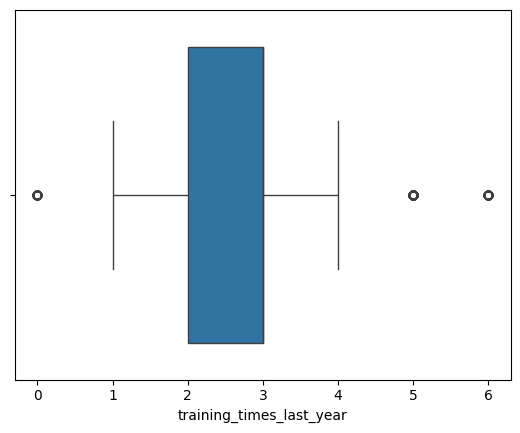

In [287]:
# este grafico nos ayuda a ver si hay valores atipicos/outliers


sns.boxplot(data=df_hr, x="training_times_last_year");

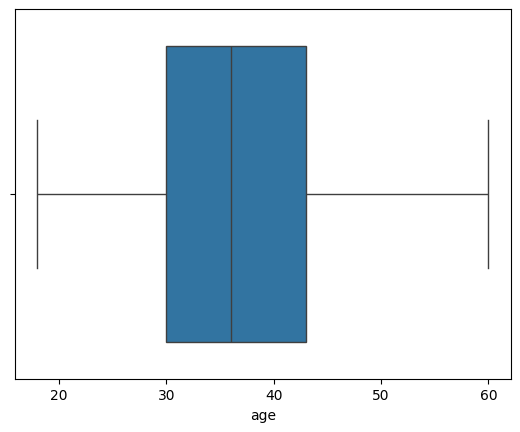

In [288]:
sns.boxplot(data=df_hr, x="age");

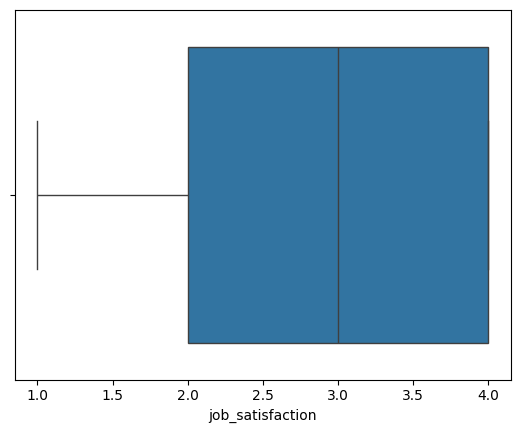

In [289]:
sns.boxplot(data=df_hr, x="job_satisfaction");

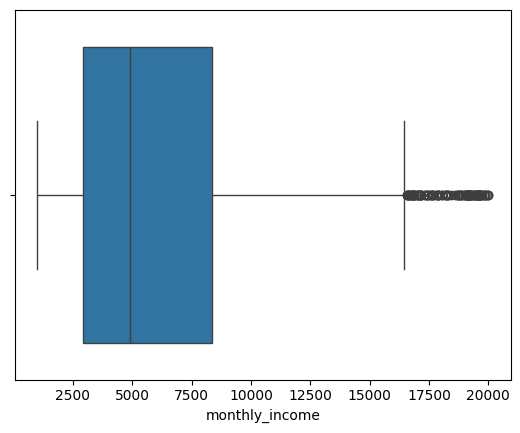

In [290]:
sns.boxplot(data=df_hr, x="monthly_income");

In [292]:

lista_num_media_mediana = ["age", "job_satisfaction", "monthly_income", "training_times_last_year"] 

df_hr[lista_num_media_mediana].agg(["mean", "median"]).T

,mean,median
age,36.942734,36.0
job_satisfaction,2.732130,3.0
monthly_income,6498.683379,4907.0
training_times_last_year,2.798119,3.0


In [293]:
# Imputamos usando la mediana para todas, porque solo en monthly_income encontramos muchos outliers 
# y en las demas no hay mucha diferencia entre media y mediana

mediana_num = df_hr[lista_num_media_mediana].median()

df_hr[lista_num_media_mediana] = df_hr[lista_num_media_mediana].fillna(mediana_num)

df_hr[lista_num_media_mediana].isnull().sum()

age                         0
job_satisfaction            0
monthly_income              0
training_times_last_year    0
dtype: int64

In [298]:
# ahora imputamos usando tecnica avanzada con la columna 'years_with_curr_manager'

iterative_imputer = IterativeImputer(random_state=42, max_iter=20)

iterative_imputado = iterative_imputer.fit_transform(df_hr[["years_with_curr_manager"]])

df_hr[["years_with_curr_manager"]] = iterative_imputado

df_hr.sample(3)


,age,attrition,business_travel,department,distance_from_home,education,education_field,employee_number,environment_satisfaction,gender,hourly_rate,job_involvement,job_level,job_role,job_satisfaction,marital_status,monthly_income,num_companies_worked,over_time,percent_salary_hike,performance_rating,relationship_satisfaction,stock_option_level,total_working_years,training_times_last_year,work_life_balance,years_at_company,years_in_current_role,years_since_last_promotion,years_with_curr_manager
1059,35,No,rarely,sales,7,1,life_sciences,1492,4,Male,76,3,1,sales_representative,3.0,Desconocido,2404.0,1,No,13,3,1,1,1,3.0,3,1,0,0,0.0
910,23,No,rarely,research_&_development,1,2,life_sciences,1270,4,Male,47,3,1,research_scientist,3.0,married,1223.0,1,No,22,4,4,1,1,2.0,3,1,0,0,1.0
767,37,No,rarely,research_&_development,3,3,other,1062,4,Female,35,3,2,healthcare_representative,2.0,single,4107.0,3,No,15,3,1,0,8,3.0,2,4,3,0,1.0


In [296]:
print(df_hr.isnull().sum())

age                           0
attrition                     0
business_travel               0
department                    0
distance_from_home            0
education                     0
education_field               0
employee_number               0
environment_satisfaction      0
gender                        0
hourly_rate                   0
job_involvement               0
job_level                     0
job_role                      0
job_satisfaction              0
marital_status                0
monthly_income                0
num_companies_worked          0
over_time                     0
percent_salary_hike           0
performance_rating            0
relationship_satisfaction     0
stock_option_level            0
total_working_years           0
training_times_last_year      0
work_life_balance             0
years_at_company              0
years_in_current_role         0
years_since_last_promotion    0
years_with_curr_manager       0
dtype: int64


In [300]:
# Guardamos el DataFrame limpio en un nuevo archivo CSV
df_hr.to_csv("df_hr_limpio.csv", index=False)

**<u>revision para limpieza</u>**


**<u>hecho:</u>**

- nombre de columnas en minuscula y separado con _ ✔️
- edad cambiar a int ✔️ 
- job role: cambiar a todo en minusculas ✔️ 
- bussines travel lo dejaria solo con rarely o con frequantly. (quitar travel).✔️ 
- departament: poner en minusculas ✔️ 
- marital status hay singled, maried, divorced, escribir homogeneo ✔️
- eliminar columna employee count ✔️
- education_field categorias en minuscula y separado con _ ✔️
- eliminar duplicados ✔️
- ver cuantos nulos tenemos ✔️




**<u>falta:</u>**
- gestion de nulos ✔️



**<u>Eliminamos columnas:</u>**

- 'employee_count', 'over_18', 'standard_hours', 'monthly_rate', 'daily_rate'✔️
- education field La dejamos ✔️